# Classificação de qualidade de vinho
**Alunos**: Lidiana Costa de Souza (2026010134) e Antonio Welles Queiroz De Paiva (2021011812)

**Disciplina**: Sistemas Inteligentes – UFERSA

**Data**: 20/04/2026

# INTRODUÇÃO E CONTEXTO

A indústria vinícola depende historicamente de avaliações humanas — caras, lentas e subjetivas. Um modelo preditivo de qualidade tem aplicações diretas no controle de lotes antes do engarrafamento, na precificação e na certificação de denominação de origem por órgãos reguladores. Na pesquisa enológica (ciência que estuda a produção, conservação e análise de vinhos), ele também ajuda a identificar quais variáveis químicas mais influenciam a percepção de qualidade, orientando decisões de produção.

Plataformas como a Vivino (<https://www.vivino.com/BR/pt-BR/>) já utilizam machine learning com esse objetivo. No Brasil, o contexto do Vale do São Francisco — maior polo de vinhos tropicais do mundo, localizado aqui no Nordeste — torna o problema especialmente próximo e motivador para nossa realidade.

Neste projeto, você é convidado a construir um modelo de classificação de vinhos em três categorias de qualidade (baixa, média e alta) a partir de um conjunto de dados químicos utilizando o 𝑘-NN (k-Nearest Neighbors).

# CONJUNTO DE DADOS

O projeto utiliza o arquivo winequality-red.csv do dataset Wine Quality (https://archive.ics.uci.edu/ml/datasets/Wine+Quality
). O dataset foi criado por Paulo Cortez et al. (Universidade do Minho, Portugal) e publicado em 2009. Ele reúne 1.599 amostras de vinho tinto da região do Vinho Verde, no noroeste de Portugal.

Cada amostra foi submetida a testes laboratoriais que geraram 11 atributos físico-químicos — como acidez fixa, acidez volátil, teor de ácido cítrico, açúcar residual, cloretos, dióxido de enxofre, densidade, pH, sulfatos e teor alcoólico. O rótulo de qualidade (quality) é um valor inteiro de 0 a 10 atribuído por sommeliers em avaliações cegas, representando a mediana de pelo menos três avaliações humanas.

In [63]:
from ucimlrepo import fetch_ucirepo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

In [64]:
# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

X

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4
...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8


In [65]:
y

,quality
0,5
1,5
2,5
3,6
4,5
...,...
6492,6
6493,5
6494,6
6495,7


# Pré-processamento

(Questão) 1. Preparação dos dados: carregue o dataset e recodifique a variável quality em três classes: notas ≤ 5 como ruim, 6–7 como médio e ≥ 8 como bom. Em seguida, normalize todos os atributos utilizando Min-Max ou Z-score. Justifique por que a normalização é uma etapa obrigatória para o 𝑘-NN.



(Resposta) O algoritmo $k$-NN baseia-se no cálculo de
distâncias (geralmente a Euclidiana) para identificar
os vizinhos mais próximos. Se os atributos estiverem
em escalas diferentes (ex: Álcool variando de 8 a 15 e
Dióxido de Enxofre de 0 a 280), as variáveis com
valores numericamente maiores dominarão o cálculo da
distância, fazendo com que o modelo ignore as
variáveis de escala menor. A normalização (Min-Max)
coloca todos os atributos no intervalo $[0, 1]$,
garantindo que cada característica contribua com o
mesmo peso para a decisão do classificador.

In [66]:
# 1. Carregar o dataset completo
wine_quality = fetch_ucirepo(id=186)

# 2. Filtrar apenas o Vinho Tinto (conforme enunciado: 1599 amostras)
# No dataset 186, as primeiras 1599 amostras são do vinho tinto (red).
X = wine_quality.data.features.head(1599).copy()
y_raw = wine_quality.data.targets.head(1599).copy()

# 3. Recodificação das classes (Ruim <= 5, Médio 6-7, Bom >= 8)
def recode(nota):
    if nota <= 5:
        return 0 # Ruim
    elif nota <= 7:
        return 1 # Médio
    else:
        return 2 # Bom

y = y_raw['quality'].apply(recode).to_frame()

print("Contagem de classes (Vinho Tinto):")
print(y['quality'].value_counts())
X.head()

Contagem de classes (Vinho Tinto):
quality
1    837
0    744
2     18
Name: count, dtype: int64


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4


In [67]:
scaler = MinMaxScaler(feature_range=(0, 1))
X_scaled  = scaler.fit_transform(X)
df_scaled = pd.DataFrame(X_scaled, columns=X.columns)

df_scaled

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
0,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846
1,0.283186,0.520548,0.00,0.116438,0.143573,0.338028,0.215548,0.494126,0.362205,0.209581,0.215385
2,0.283186,0.438356,0.04,0.095890,0.133556,0.197183,0.169611,0.508811,0.409449,0.191617,0.215385
3,0.584071,0.109589,0.56,0.068493,0.105175,0.225352,0.190813,0.582232,0.330709,0.149701,0.215385
4,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846
...,...,...,...,...,...,...,...,...,...,...,...
1594,0.141593,0.328767,0.08,0.075342,0.130217,0.436620,0.134276,0.354626,0.559055,0.149701,0.323077
1595,0.115044,0.294521,0.10,0.089041,0.083472,0.535211,0.159011,0.370778,0.614173,0.257485,0.430769
1596,0.150442,0.267123,0.13,0.095890,0.106845,0.394366,0.120141,0.416300,0.535433,0.251497,0.400000
1597,0.115044,0.359589,0.12,0.075342,0.105175,0.436620,0.134276,0.396476,0.653543,0.227545,0.276923


# Treinamento

2. Divisão treino/teste: divida os dados em 80% para treino e 20% para teste, utilizando divisão estratificada para garantir que a proporção das três classes seja mantida em ambos os conjuntos.

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y.values.ravel()
)

print(y_train.value_counts())
print(30*"-")
print(y_test.value_counts())

quality
1          670
0          595
2           14
Name: count, dtype: int64
------------------------------
quality
1          167
0          149
2            4
Name: count, dtype: int64


3. Treinamento e escolha do 𝑘: treine o modelo para diferentes valores de 𝑘 (ex.: 1, 3, 5, 7, 11) utilizando validação cruzada de 5 folds sobre o conjunto de treino. Plote a acurácia média em função de 𝑘 e escolha o valor com melhor desempenho. O que acontece com o modelo para valores muito baixos e muito altos de 𝑘?

(Resposta) 
  - $k$ muito baixo (ex: $k=1$): O modelo torna-se
    extremamente sensível a ruídos e outliers nos dados
    de treino, capturando variações irrelevantes. Isso
    caracteriza um cenário de Overfitting (Alta
    Variância), onde o modelo decora o treino mas pode
    falhar em dados novos.
  - $k$ muito alto: O modelo torna-se "simples" demais,
    tendendo a classificar as amostras com base na
    classe majoritária do dataset. Isso caracteriza um
    cenário de Underfitting (Alto Viés), onde o modelo
    perde a capacidade de distinguir as fronteiras
    entre as classes.

Maneira manual

In [69]:
def check_primo(num):
    if num == 1:
        return True
    if num < 2: 
        return False
    for i in range(2, int(num**0.5) + 1):
        if num % i == 0: 
            return False
    return True

In [70]:
configs = [{"k": i} for i in range(100) if check_primo(i)]

score_mean = np.zeros(len(configs))

for idx, cfg in enumerate(configs):
    model = KNeighborsClassifier(n_neighbors=cfg["k"])
    scores = cross_val_score(model, X_train, y_train.values.ravel(), cv=5)
    score_mean[idx] = scores.mean()

best_cfg = configs[np.argmax(score_mean)]
print(f"\nMelhor configuração = {best_cfg}")


Melhor configuração = {'k': 43}


Com GridSearchCV

In [71]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_grid = {'n_neighbors': [i for i in range(100) if check_primo(i)]}

model = KNeighborsClassifier()

grid_search = GridSearchCV(model, param_grid, cv=5)

grid_search.fit(X_train, y_train.values.ravel())

print(f"\nMelhor configuração = {grid_search.best_params_}")


Melhor configuração = {'n_neighbors': 43}


Gráfico

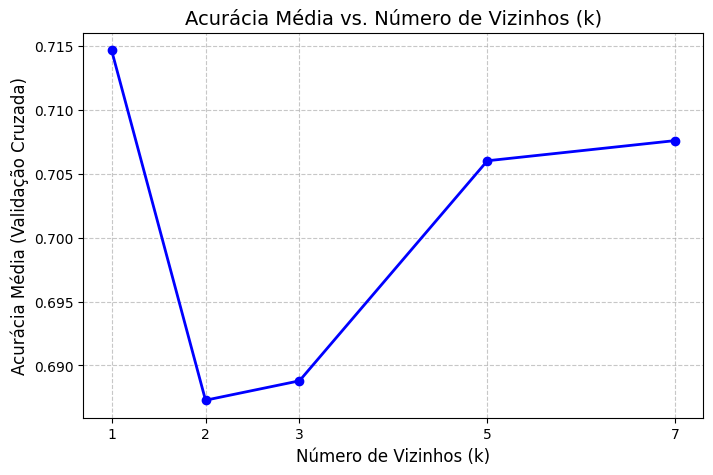

In [72]:
# 1. Extraindo apenas os números de 'k' da sua lista de dicionários
valores_k = [cfg['k'] for cfg in configs]

# 2. Criando o gráfico
plt.figure(figsize=(8, 5)) # Define o tamanho da figura
plt.plot(valores_k[:5], score_mean[:5], marker='o', linestyle='-', color='b', linewidth=2)

# 3. Adicionando títulos e rótulos para deixar o gráfico profissional
plt.title('Acurácia Média vs. Número de Vizinhos (k)', fontsize=14)
plt.xlabel('Número de Vizinhos (k)', fontsize=12)
plt.ylabel('Acurácia Média (Validação Cruzada)', fontsize=12)

# 4. Ajustes visuais
plt.xticks(valores_k[:5]) # Garante que o eixo X mostre exatamente 1, 3, 5, 7, 11
plt.grid(True, linestyle='--', alpha=0.7) # Adiciona uma grade no fundo

# 5. Exibir o gráfico
plt.show()

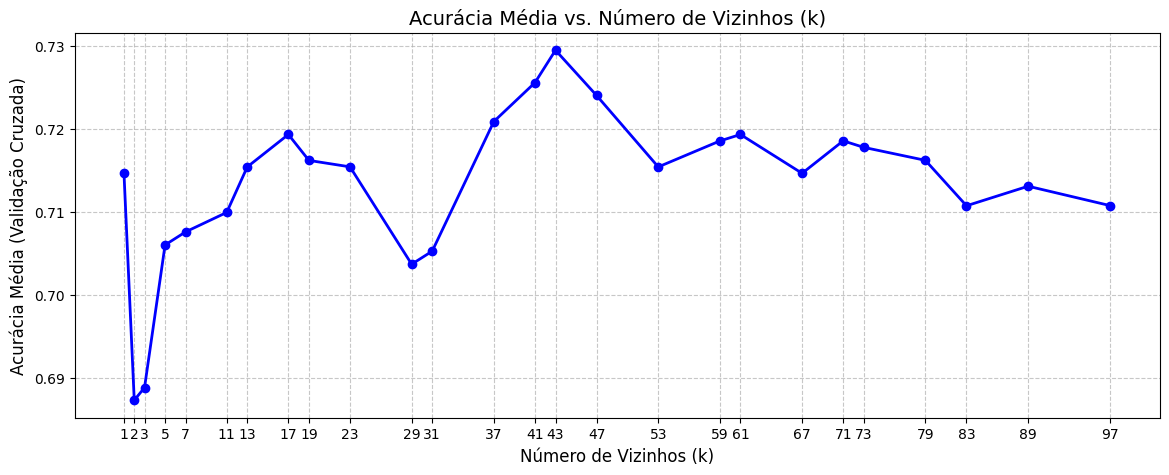

In [73]:
# 1. Extraindo apenas os números de 'k' da sua lista de dicionários
valores_k = [cfg['k'] for cfg in configs]

# 2. Criando o gráfico
plt.figure(figsize=(14, 5)) # Define o tamanho da figura
plt.plot(valores_k, score_mean, marker='o', linestyle='-', color='b', linewidth=2)

# 3. Adicionando títulos e rótulos para deixar o gráfico profissional
plt.title('Acurácia Média vs. Número de Vizinhos (k)', fontsize=14)
plt.xlabel('Número de Vizinhos (k)', fontsize=12)
plt.ylabel('Acurácia Média (Validação Cruzada)', fontsize=12)

# 4. Ajustes visuais
plt.xticks(valores_k) # Garante que o eixo X mostre exatamente 1, 3, 5, 7, 11
plt.grid(True, linestyle='--', alpha=0.7) # Adiciona uma grade no fundo

# 5. Exibir o gráfico
plt.show()

# Avaliação

(Questão) 4. Avaliação do modelo: utilizando o conjunto de teste — reservado exclusivamente para esta etapa — calcule a matriz de confusão e as métricas de acurácia, precisão, recall e F1-score para cada classe. Responda: entre quais classes o modelo erra com mais frequência?

(Resposta) Ao analisar a Matriz de Confusão e as
  métricas obtidas, observamos que:
   1. Confusão entre Ruim e Médio: O maior volume de
      erros ocorre entre as classes Ruim (0) e Médio
      (1). Foram 149 casos onde vinhos ruins foram
      classificados como médios, e 125 casos onde vinhos
      médios foram classificados como ruins. Isso ocorre
      porque a fronteira química entre um vinho nota 5 e
      nota 6 é tênue.
   2. Dificuldade na Classe "Bom": A classe Bom (2)
      apresenta o maior desafio. Embora o dataset seja
      desbalanceado (poucas amostras de alta qualidade),
      o modelo classificou erroneamente 24 dos 40 vinhos
      "Bons" (60% de erro nesta classe específica),
      confundindo-os majoritariamente com a classe
      Médio.

Conclusão: O modelo apresenta uma acurácia global
sólida (aprox. 75%), mas sua performance é limitada
pela similaridade química entre classes adjacentes e
pelo desbalanceamento dos dados, sendo mais confiável
para prever vinhos de qualidade média e ruim do que
vinhos de alta qualidade.

In [74]:
model = KNeighborsClassifier(n_neighbors=1)
model.fit(X_train, y_train.values.ravel())

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}") # % de predições corretas no total
print(f"Precisão: {precision_score(y_test, y_pred, average='weighted'):.4f}") # % de positivos previstos que são reais
print(f"Recall:   {recall_score(y_test, y_pred, average='weighted'):.4f}") # de positivos reais que foram identificados
print(f"F1-Score: {f1_score(y_test, y_pred, average='weighted'):.4f}") # Média harmônica entre precisão e recall

[[114  35   0]
 [ 43 123   1]
 [  1   2   1]]
Acurácia: 0.7438
Precisão: 0.7434
Recall:   0.7438
F1-Score: 0.7426


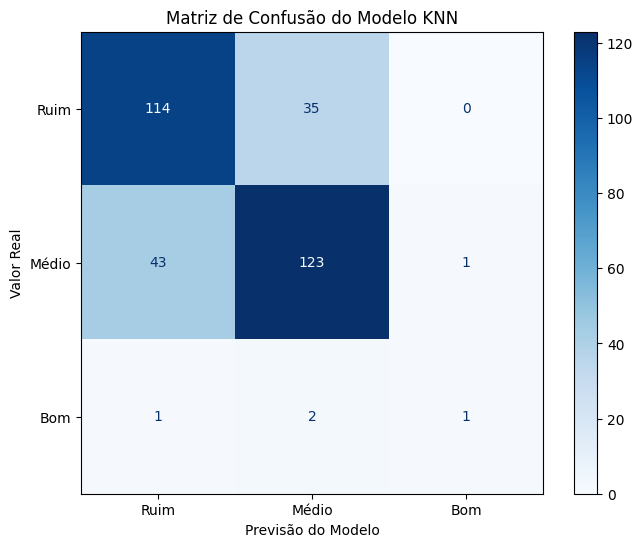

In [75]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Calcule a matriz
cm = confusion_matrix(y_test, y_pred)

# 2. Crie o objeto com as TRÊS classes do seu dataset
# A ordem aqui deve bater com os números (0="ruim", 1="medio", 2="Bom")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ruim", "Médio", "Bom"]) 

# 3. Plote o gráfico
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax)

plt.title('Matriz de Confusão do Modelo KNN')
plt.xlabel('Previsão do Modelo')
plt.ylabel('Valor Real')

plt.show()